<a href="https://colab.research.google.com/github/ntqn23521128/PTDLKD_IS403.Q11/blob/main/EDA_Bank_Churn_Prediction_Nh%C3%B3m_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 📌 1) Import các thư viện cần thiết
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from IPython.display import display, HTML

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# ============================================================
# 📌 2) Tải dữ liệu
# ============================================================

df = pd.read_csv("Churn_Modelling.csv")

# ============================================================
# 📌 3) Khám phá thông tin tổng quan
# ============================================================

print("📌 Thông tin tổng quan về dữ liệu:")
print(df.info())

print("\n📌 5 dòng đầu của dữ liệu:")
display(HTML(df.head().to_html()))

print("\n📌 Kiểm tra dữ liệu bị thiếu (Missing values):")
print(df.isnull().sum())

print("\n📌 Thống kê mô tả dữ liệu:")
display(HTML(df.describe().to_html()))

📌 Thông tin tổng quan về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

📌 5 dòng đầu của dữ liệu:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



📌 Kiểm tra dữ liệu bị thiếu (Missing values):
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

📌 Thống kê mô tả dữ liệu:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


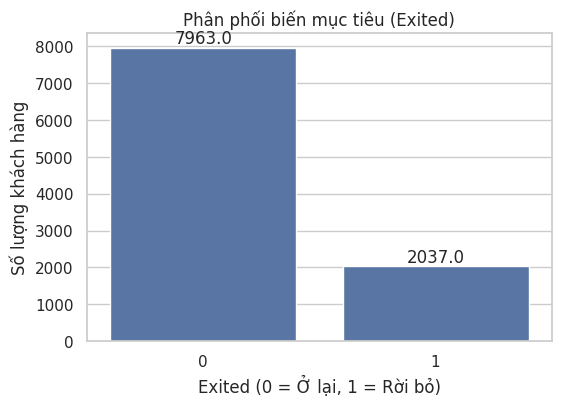

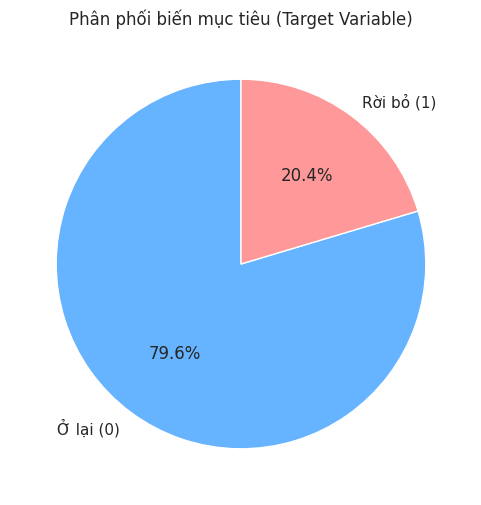

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 4) XỬ LÝ CỘT KHÔNG CẦN THIẾT
columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


# 5) PHÂN PHỐI BIẾN MỤC TIÊU (CHURN)
# --- Biểu đồ cột (Bar Chart) ---
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x="Exited")
plt.title("Phân phối biến mục tiêu (Exited)")
plt.xlabel("Exited (0 = Ở lại, 1 = Rời bỏ)")
plt.ylabel("Số lượng khách hàng")

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()


# --- Biểu đồ tròn (Pie Chart)
churn_counts = df["Exited"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(churn_counts,
        labels=['Ở lại (0)', 'Rời bỏ (1)'],
        autopct='%1.1f%%',
        colors=['#66b3ff','#ff9999'],
        startangle=90) # Xoay biểu đồ cho đẹp
plt.title("Phân phối biến mục tiêu (Target Variable)")
plt.show()

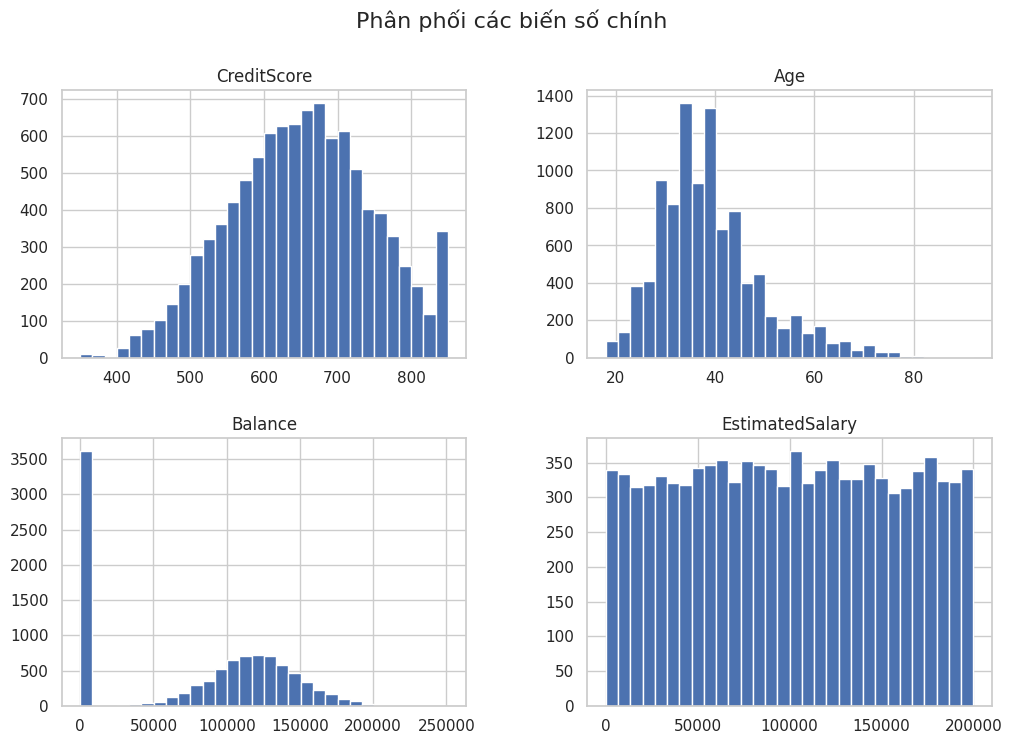

In [ ]:
# 6) PHÂN PHỐI CÁC BIẾN SỐ QUAN TRỌNG (HISTOGRAM)
num_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

df[num_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Phân phối các biến số chính", fontsize=16)
plt.show()


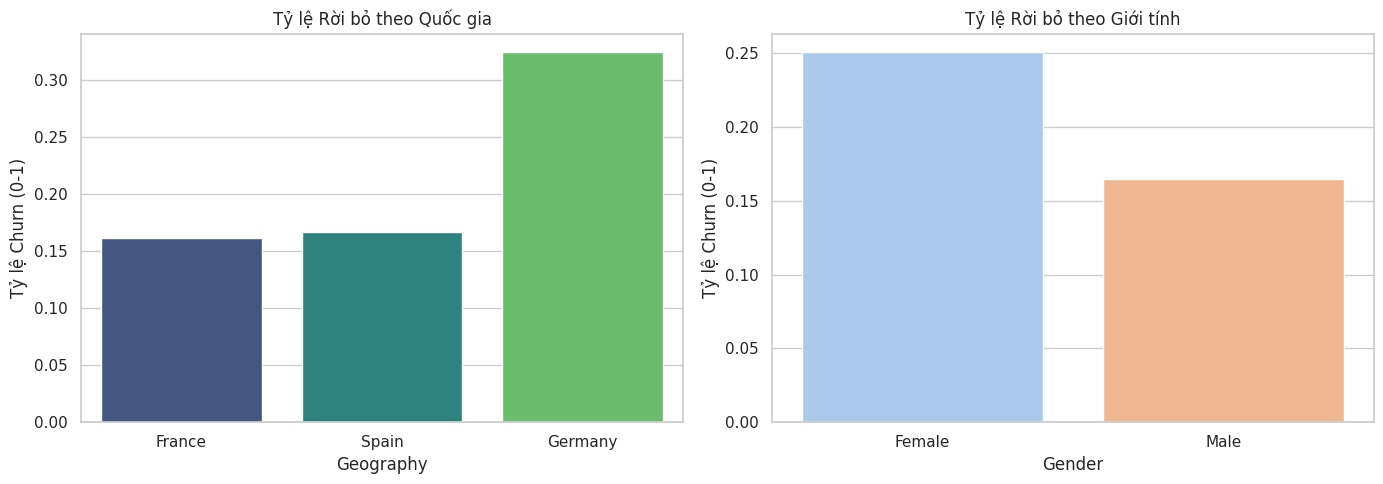

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 7) TỶ LỆ CHURN THEO QUỐC GIA & GIỚI TÍNH (Biểu đồ cột) ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Theo Quốc gia
sns.barplot(
    data=df_clean,
    x='Geography',
    y='Exited',
    hue='Geography',
    legend=False,
    ax=ax[0],
    palette='viridis',
    errorbar=None
)
ax[0].set_title('Tỷ lệ Rời bỏ theo Quốc gia')
ax[0].set_ylabel('Tỷ lệ Churn (0-1)')

# 2. Theo Giới tính
sns.barplot(
    data=df_clean,
    x='Gender',
    y='Exited',
    hue='Gender',
    legend=False,
    ax=ax[1],
    palette='pastel',
    errorbar=None
)
ax[1].set_title('Tỷ lệ Rời bỏ theo Giới tính')
ax[1].set_ylabel('Tỷ lệ Churn (0-1)')

plt.tight_layout()
plt.show()


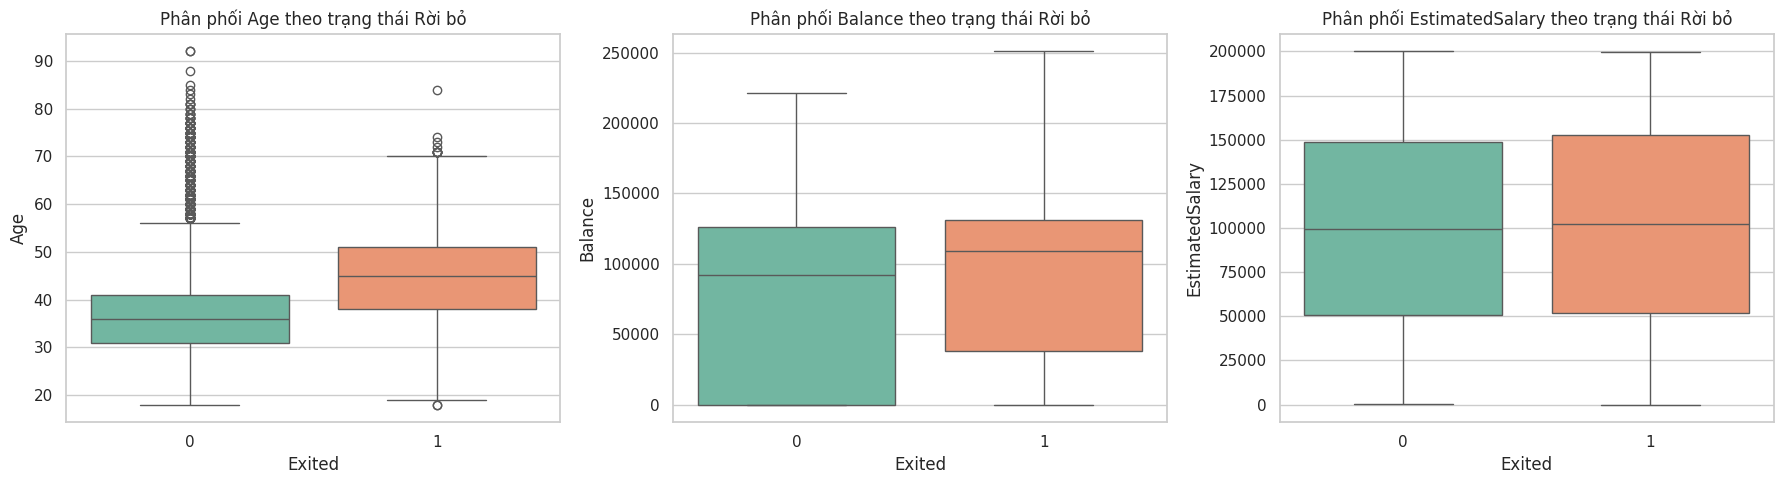

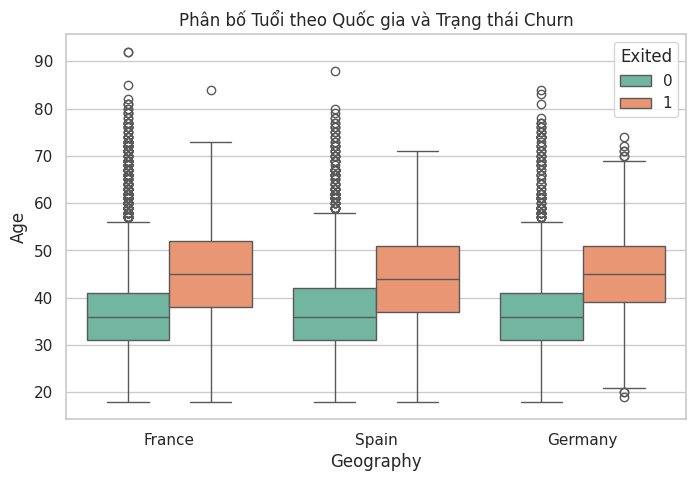

In [ ]:
# 📌 8) Boxplot cho các biến số theo Churn
# Xem phân phối của Tuổi, Số dư, Lương theo nhóm Churn/Không Churn
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
cols = ['Age', 'Balance', 'EstimatedSalary']

for i, col in enumerate(cols):
    sns.boxplot(
        data=df_clean,
        x='Exited',
        y=col,
        hue='Exited',
        legend=False,
        ax=ax[i],
        palette='Set2'
    )
    ax[i].set_title(f'Phân phối {col} theo trạng thái Rời bỏ')

plt.tight_layout()
plt.show()


# 9) PHÂN TÍCH ĐA BIẾN: QUỐC GIA - TUỔI - CHURN
plt.figure(figsize=(8, 5))
# Lưu ý: Mình đổi 'temp_df' thành 'df_clean' để code chạy được (vì temp_df chưa được định nghĩa)
sns.boxplot(data=df_clean, x="Geography", y="Age", hue="Exited", palette='Set2')
plt.title("Phân bố Tuổi theo Quốc gia và Trạng thái Churn")
plt.show()

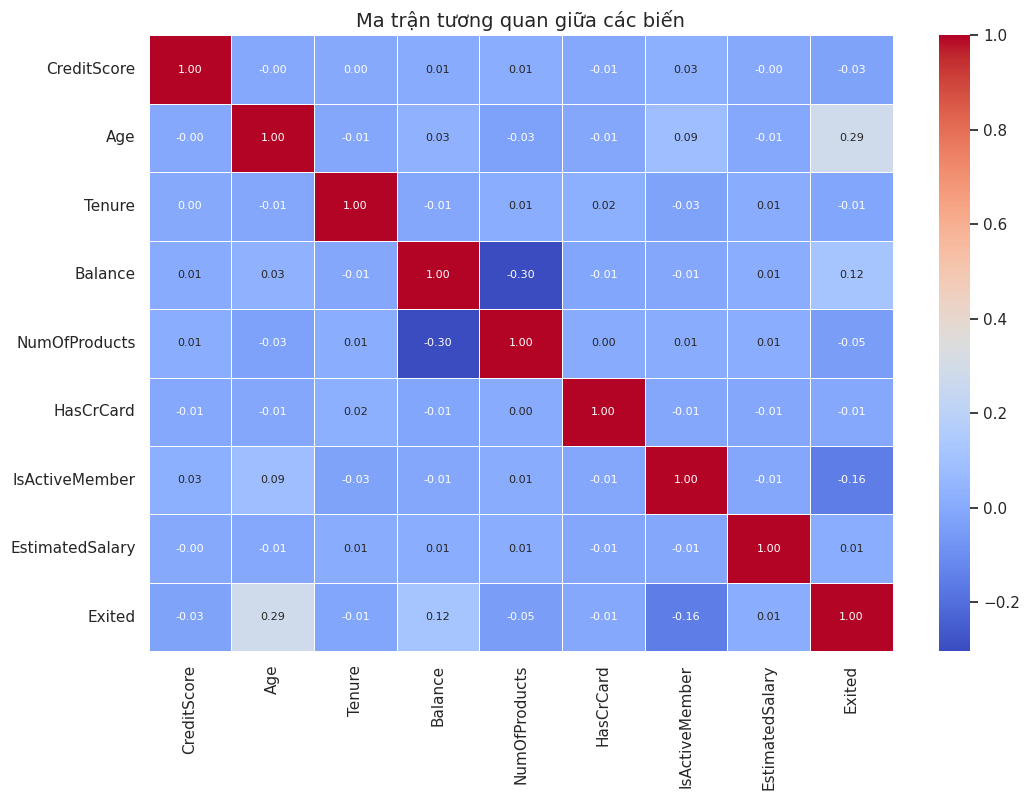

In [ ]:
# 📌 10) Ma trận tương quan (Heatmap)

plt.figure(figsize=(12, 8))

# Tính toán ma trận tương quan
corr = df.corr(numeric_only=True)

# Vẽ heatmap
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={"size": 8}
)

plt.title("Ma trận tương quan giữa các biến", fontsize=14)
plt.show()

